In [2]:
#Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
csv = 'Optogenetics-20241202T112946Z-001/Optogenetics/ATR-/speeds_and_coordinates_02piworm16_2_updated.csv'# Read the CSV file
data = pd.read_csv(csv)

In [4]:
# Display the first few rows of the dataset
data.head()
#Summary of data
print(data.describe())

              Frame         Speed             X             Y  Changed Pixels  \
count  86392.000000  86392.000000  79940.000000  79940.000000    86392.000000   
mean    5400.000000      4.042680    231.283756    378.333178       36.790802   
std     3117.420807     32.481805     78.810639    112.353638      366.883584   
min        1.000000      0.000000     22.600000      1.555556        0.000000   
25%     2700.000000      0.380577    185.503378    320.775311        9.000000   
50%     5400.000000      0.949954    230.982747    370.254640       20.000000   
75%     8100.000000      2.104929    251.551996    492.896537       39.000000   
max    10799.000000   1056.534038    662.813149    648.662813    47133.000000   

        Light_Pulse  
count  86392.000000  
mean       0.004445  
std        0.066522  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  


In [5]:
#Correct Frame numbers --> now all frames are unique, use as ID column, does not restart after 10800 s
data["continuous_frames"] = data.index + 1
data['Instantaneous Distance'] = np.sqrt(
        (data['X'].diff() ** 2) + (data['Y'].diff() ** 2)
    ).fillna(0)
data['Total Distance'] = data['Instantaneous Distance'].cumsum()
data['Angle'] = np.arctan2(data['Y'].diff(), data['X'].diff()).fillna(0)    
data['Angular Change'] = data['Angle'].diff().abs().fillna(0)
# NB: we have change in angle instead of angular speed: same thing as angular speed depends on change in angle over time

In [6]:
print(data.shape)
print(f"Total time recorded: {round(data.shape[0]*2/3600,3)} hours")

(86392, 11)
Total time recorded: 47.996 hours


In [7]:
#Add Euclidean Speed to the next column
data['euclidean_speed'] = np.sqrt((data['X'].diff())**2 + (data['Y'].diff())**2) * 2
data['euclidean_speed'] = data['euclidean_speed'].shift(-1)

data['speed_diff'] = data['euclidean_speed'] - data['Speed']
data['speed_diff'] = np.where(abs(data['speed_diff']) < 0.01, 0, data['speed_diff'])

print(data['speed_diff'].value_counts())

speed_diff
 0.000000      79229
-140.990845        1
 40.322539         1
 35.686050         1
 41.008386         1
               ...  
 67.109449         1
 54.732783         1
 20.393708         1
-45.357528         1
 36.762866         1
Name: count, Length: 396, dtype: int64


In [8]:
# print(data[['euclidean_speed', 'Speed', 'speed_diff']])
non_zero_count = (data['speed_diff'] != 0).sum()

print(f"Number of rows where speed_diff is not 0: {non_zero_count}")

Number of rows where speed_diff is not 0: 7163


In [9]:
# Step 1: Check for "no significant movement" with a tolerance of 0.5
tolerance_movement = 0.5
# data['no_movement'] = (data['X'].diff().fillna(0).abs() < tolerance_movement) & (data['Y'].diff().fillna(0).abs() < tolerance_movement)
tolerance_speed = 0.1
data['no_movement'] = data['Speed'].abs() < tolerance_speed

# Step 2: Count consecutive no-movement frames
# Use a cumulative counter that resets when movement is detected
data['no_movement_count'] = data['no_movement'].cumsum() - data['no_movement'].cumsum().where(~data['no_movement']).ffill().fillna(0).astype(int)

# Step 3: Identify when no movement reaches the threshold
threshold = 153
data['dead'] = data['no_movement_count'] >= threshold

# Step 4: Record the first row where the worm is declared dead
dead_row = data[data['dead']].index.min()

if pd.notna(dead_row):
    print(f"The worm is declared dead at row index: {dead_row}")
    # Display relevant columns for verification
    print(data[['Frame', 'X', 'Y', 'Changed Pixels', 'Speed', 'no_movement', 'no_movement_count', 'dead']].iloc[max(dead_row - 3, 0):min(dead_row + 3, len(data) - 1)])
else:
    print("The worm never reaches the dead threshold.")




The worm is declared dead at row index: 34370
       Frame   X   Y  Changed Pixels  Speed  no_movement  no_movement_count  \
34367   1971 NaN NaN               0    0.0         True                150   
34368   1972 NaN NaN               0    0.0         True                151   
34369   1973 NaN NaN               0    0.0         True                152   
34370   1974 NaN NaN               0    0.0         True                153   
34371   1975 NaN NaN               0    0.0         True                154   
34372   1976 NaN NaN               0    0.0         True                155   

        dead  
34367  False  
34368  False  
34369  False  
34370   True  
34371   True  
34372   True  


In [10]:
#time
# 2x : frame rate = 0,5 frames per second

def calculate_time_units(frames):
    """
    Calculate elapsed time in seconds, minutes, hours, and days for each frame.

    Args:
    frames (array-like): Continuous frame numbers.

    Returns:
    pandas.DataFrame: A DataFrame with columns for seconds, minutes, hours, and days.

    To run:
    time_columns = calculate_time_units(data['continuous_frames'])
    data = pd.concat([data, time_columns], axis=1)
    """
    frames = np.array(frames)  # Ensure input is a numpy array for vectorized computation

    # Calculate elapsed time in seconds
    elapsed_seconds = 2 * (frames)
    
    # Convert to other units
    elapsed_minutes = elapsed_seconds / 60
    elapsed_hours = elapsed_minutes / 60
    elapsed_days = elapsed_hours / 24

    # Return as a DataFrame
    return pd.DataFrame({
        'time_seconds': elapsed_seconds,
        'time_minutes': elapsed_minutes,
        'time_hours': elapsed_hours,
        'time_days': elapsed_days
    })



In [11]:
time_columns = calculate_time_units(data['continuous_frames'])
data = pd.concat([data, time_columns], axis=1)
print(data)
data.head()

       Frame     Speed           X           Y  Changed Pixels  Light_Pulse  \
0          1  0.000000         NaN         NaN             156            0   
1          2  0.000000         NaN         NaN               0            0   
2          3  0.000000         NaN         NaN               0            0   
3          4  0.000000         NaN         NaN               0            0   
4          5  0.000000         NaN         NaN               0            0   
...      ...       ...         ...         ...             ...          ...   
86387  10795  0.348790  137.933921  327.176211               4            0   
86388  10796  0.761737  137.995633  327.013100               7            0   
86389  10797  0.536406  137.867257  327.371681               9            0   
86390  10798  1.278019  137.832599  327.105727              20            0   
86391  10799  0.000000  137.814978  326.466960               0            0   

       continuous_frames  Instantaneous Distance  T

,Frame,Speed,X,Y,Changed Pixels,Light_Pulse,continuous_frames,Instantaneous Distance,Total Distance,Angle,Angular Change,euclidean_speed,speed_diff,no_movement,no_movement_count,dead,time_seconds,time_minutes,time_hours,time_days
0,1,0.0,NaN,NaN,156,0,1,0.0,0.0,0.0,0.0,NaN,NaN,True,1,False,2,0.033333,0.000556,0.000023
1,2,0.0,NaN,NaN,0,0,2,0.0,0.0,0.0,0.0,NaN,NaN,True,2,False,4,0.066667,0.001111,0.000046
2,3,0.0,NaN,NaN,0,0,3,0.0,0.0,0.0,0.0,NaN,NaN,True,3,False,6,0.100000,0.001667,0.000069
3,4,0.0,NaN,NaN,0,0,4,0.0,0.0,0.0,0.0,NaN,NaN,True,4,False,8,0.133333,0.002222,0.000093
4,5,0.0,NaN,NaN,0,0,5,0.0,0.0,0.0,0.0,NaN,NaN,True,5,False,10,0.166667,0.002778,0.000116


In [12]:
#speed variability
def calculate_speed_variability(data, interval, THEC):
    """
    Calculate speed variability over specified intervals.

    Args:
    data (pd.DataFrame): DataFrame containing at least the 'euclidean_speed' column.
    interval (int): Number of rows (frames) per interval.

    Returns:
    pd.DataFrame: DataFrame with new columns:
                  - 'std_speed': Standard deviation of speed in each interval
                  - 'mean_speed': Mean speed in each interval
                  - 'speed_variability': Ratio of std to mean in each interval
    """
    # Validate input
    if 'euclidean_speed' not in data.columns:
        raise ValueError("The DataFrame must contain a column named 'euclidean_speed'.")

    data['RoamingIndic'] = (data['euclidean_speed'] > THEC).astype(int)
    #data['Roaming_speed'] = data['Roaming2'][data['RoamingIndic'] == 1]
    
    # Calculate rolling statistics based on intervals
    rolling_std = data['euclidean_speed'].rolling(window=interval, min_periods=1).std()
    rolling_mean = data['euclidean_speed'].rolling(window=interval, min_periods=1).mean()
    #roaming_fraction = data['RoamingIndic'].sum() / len(data)

    # Assign computed values to new columns
    data['std_speed'] = rolling_std
    data['mean_speed'] = rolling_mean
    data['speed_variability'] = data['std_speed'] / data['mean_speed']
    data['roaming_frac'] = data['RoamingIndic'].rolling(window=interval, min_periods=1).mean()
    # Propagate interval values to all rows within the interval
    for col in ['std_speed', 'mean_speed', 'speed_variability']:
        data[col] = data[col].shift(-interval + 1).fillna(method='bfill')
        
    return data

def plot_data_over_interval(x, y, interval, x_label, y_label):
    """
    Plot speed variability over time.

    Args:
    data (pd.DataFrame): DataFrame containing 'speed_variability' and 'time'.
    interval (int): Interval used for calculations (used for graphing notes).
    """
    plt.figure(figsize=(10, 6))
    # Plot speed variability against time
    plt.plot(x, y, label=y_label, color='blue', linewidth=1.5)
    plt.title(f"{y_label} Over Time (Interval = {interval} frames)")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    # plt.legend()
    plt.grid()
    plt.show()



In [13]:
data.head()


,Frame,Speed,X,Y,Changed Pixels,Light_Pulse,continuous_frames,Instantaneous Distance,Total Distance,Angle,Angular Change,euclidean_speed,speed_diff,no_movement,no_movement_count,dead,time_seconds,time_minutes,time_hours,time_days
0,1,0.0,NaN,NaN,156,0,1,0.0,0.0,0.0,0.0,NaN,NaN,True,1,False,2,0.033333,0.000556,0.000023
1,2,0.0,NaN,NaN,0,0,2,0.0,0.0,0.0,0.0,NaN,NaN,True,2,False,4,0.066667,0.001111,0.000046
2,3,0.0,NaN,NaN,0,0,3,0.0,0.0,0.0,0.0,NaN,NaN,True,3,False,6,0.100000,0.001667,0.000069
3,4,0.0,NaN,NaN,0,0,4,0.0,0.0,0.0,0.0,NaN,NaN,True,4,False,8,0.133333,0.002222,0.000093
4,5,0.0,NaN,NaN,0,0,5,0.0,0.0,0.0,0.0,NaN,NaN,True,5,False,10,0.166667,0.002778,0.000116


C:\Users\srush\AppData\Local\Temp\ipykernel_22024\1519134371.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[col] = data[col].shift(-interval + 1).fillna(method='bfill')


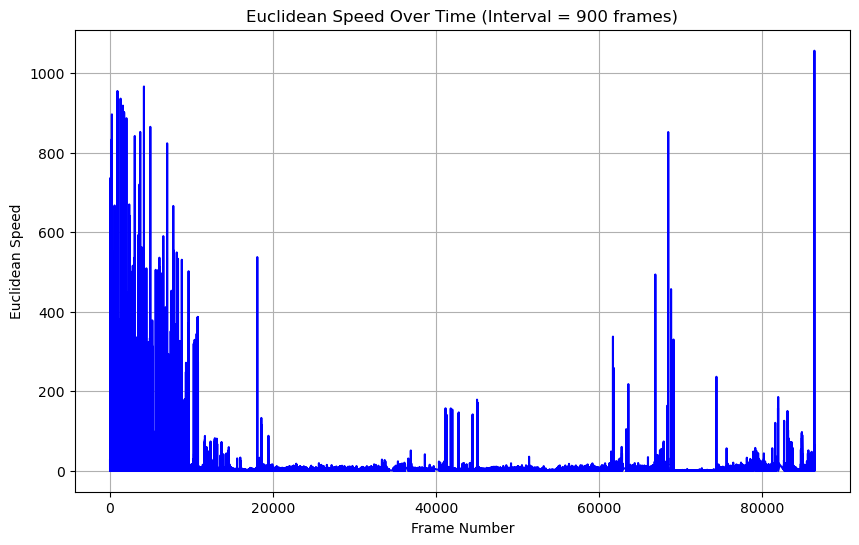

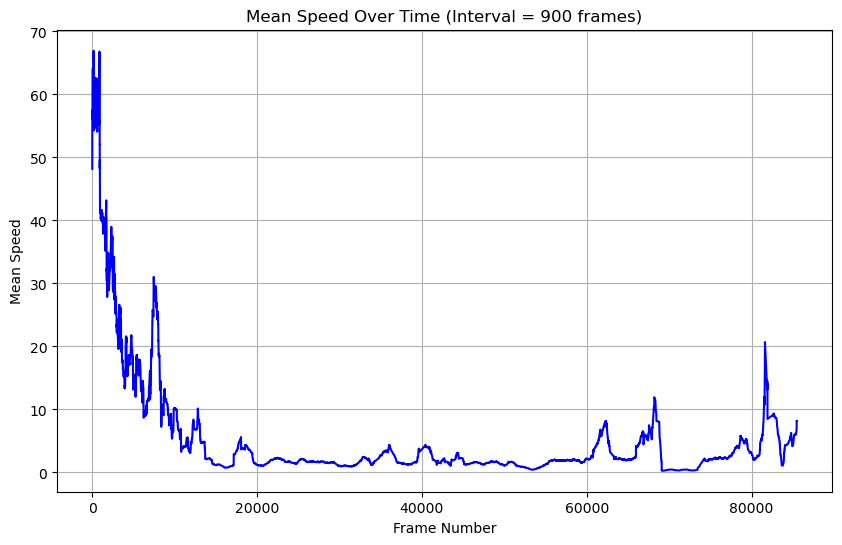

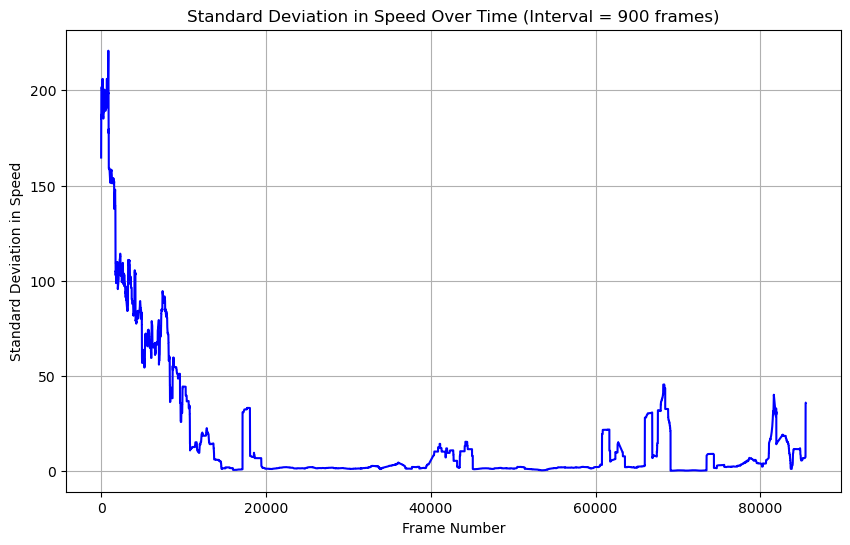

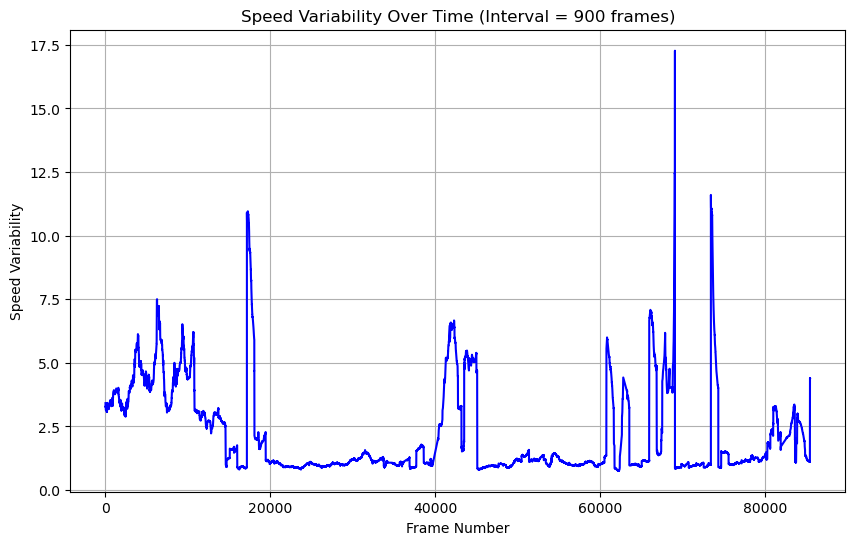

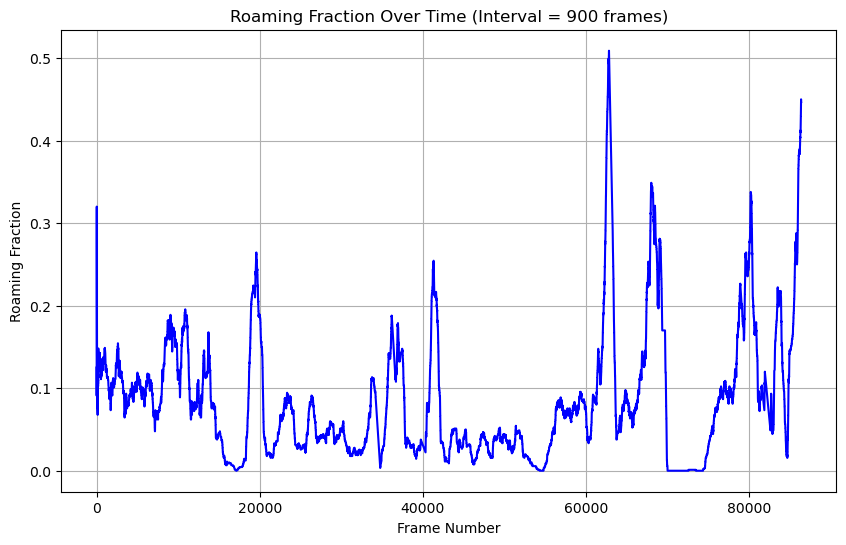

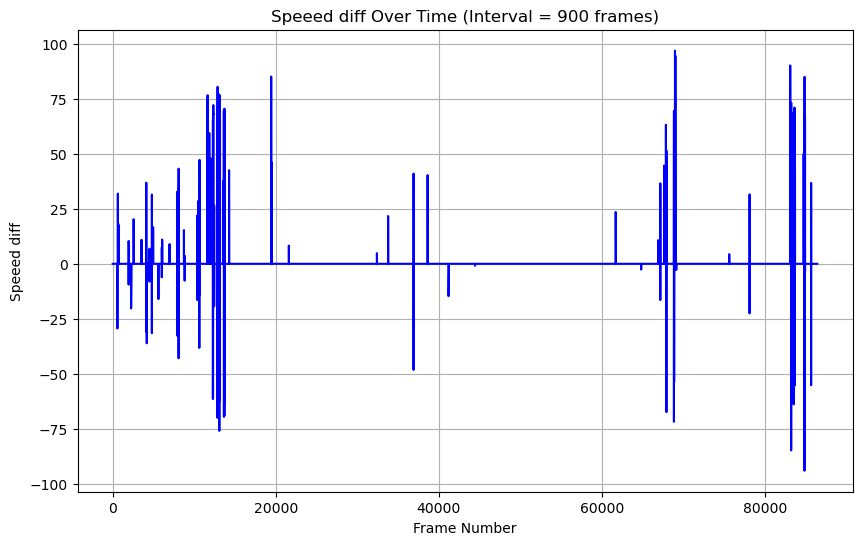

In [14]:
# Define a global variable for the interval
INTERVAL = 900  # Default interval; can be changed globally
THEC = 5


data_updated = calculate_speed_variability(data, interval=INTERVAL, THEC=THEC)
data_updated = data_updated[data_updated['speed_diff'] <= 100]
data_updated = data_updated[data_updated['speed_diff'] >= -100]
# Check the result
# print(data_updated.head(20))

# Plot speed variability
plot_data_over_interval(data_updated.index, data_updated['euclidean_speed'], x_label = "Frame Number", y_label="Euclidean Speed", interval=INTERVAL)
#plot_data_over_interval(data_updated.index, data_updated['Light_Pulse'], x_label = "Frame Number", y_label="Light Pulse", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['mean_speed'], x_label = "Frame Number", y_label="Mean Speed", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['std_speed'], x_label = "Frame Number", y_label="Standard Deviation in Speed", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['speed_variability'], x_label = "Frame Number", y_label="Speed Variability", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['roaming_frac'], x_label = "Frame Number", y_label="Roaming Fraction", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['speed_diff'], x_label = "Frame Number", y_label="Speeed diff", interval=INTERVAL)
#plot_data_over_interval(data_updated.index, data_updated['Roaming_speed'], x_label = "Frame Number", y_label="Roaming Speed", interval=INTERVAL)





In [15]:
data = data.dropna(subset=['X', 'Y']) # Drop rows with missing X or Y values
data.head()
data


,Frame,Speed,X,Y,Changed Pixels,Light_Pulse,continuous_frames,Instantaneous Distance,Total Distance,Angle,...,dead,time_seconds,time_minutes,time_hours,time_days,RoamingIndic,std_speed,mean_speed,speed_variability,roaming_frac
7,8,26.228659,235.000000,190.500000,124,0,8,0.000000,0.000000,0.000000,...,False,16,0.266667,0.004444,0.000185,1,164.696845,48.193475,3.417410,0.125000
8,9,0.335585,226.666667,200.626263,3,0,9,13.114330,13.114330,2.259371,...,False,18,0.300000,0.005000,0.000208,0,168.650780,49.703730,3.393121,0.111111
9,10,0.000000,226.630000,200.790000,0,0,10,0.167793,13.282122,1.791098,...,False,20,0.333333,0.005556,0.000231,0,172.481861,51.254786,3.365185,0.100000
10,11,0.612709,226.630000,200.790000,2,0,11,0.000000,13.282122,0.000000,...,False,22,0.366667,0.006111,0.000255,0,176.241421,52.811449,3.337182,0.090909
11,12,13.122596,226.775510,200.520408,126,0,12,0.306354,13.588477,-1.075862,...,False,24,0.400000,0.006667,0.000278,1,176.241722,52.810440,3.337252,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86387,10795,0.348790,137.933921,327.176211,4,0,86388,0.082414,180462.614356,-1.350716,...,False,172776,2879.600000,47.993333,1.999722,0,NaN,NaN,NaN,0.446667
86388,10796,0.761737,137.995633,327.013100,7,0,86389,0.174395,180462.788751,-1.209095,...,False,172778,2879.633333,47.993889,1.999745,0,NaN,NaN,NaN,0.446667
86389,10797,0.536406,137.867257,327.371681,9,0,86390,0.380869,180463.169620,1.914592,...,False,172780,2879.666667,47.994444,1.999769,0,NaN,NaN,NaN,0.446667
86390,10798,1.278019,137.832599,327.105727,20,0,86391,0.268203,180463.437823,-1.700380,...,False,172782,2879.700000,47.995000,1.999792,0,NaN,NaN,NaN,0.446667


In [16]:
def find_death_row(data, change_col='Changed Pixels', threshold=5, window=10, persistence=0.9):
    """
    Find the first row where the worm is considered "dead."
    
    Args:
        data (pd.DataFrame): The worm's trajectory data.
        change_col (str): Column indicating changes in pixels.
        threshold (int): Threshold below which the worm is considered inactive.
        window (int): Number of subsequent rows to check for inactivity.
        persistence (float): Fraction of rows in the window that must satisfy the condition.
    
    Returns:
        int: Index of the death row or -1 if no such row is found.
    """
    for i in range(len(data) - window):
        # Check if the current row satisfies the condition
        if data.loc[i, change_col] < threshold:
            # Check the persistence condition in the window
            subsequent = data[change_col].iloc[i:i+window]
            if (subsequent < threshold).sum() >= persistence * window:
                return i
    return -1  # Return -1 if no death row is found

# Reset the index of the DataFrame
data = data.reset_index(drop=True)

death_row = find_death_row(data, change_col='Changed Pixels', threshold=5, window=500, persistence=0.9)
print(f"Death row: {death_row}")
final_age = data['time_hours'].iloc[death_row]
print(f"The worm lived: {final_age/24} days.")

Death row: -1
The worm lived: 1.9998148148148147 days.


In [17]:
threshold = 500
tolerance_speed = 0.1
speed_difference_threshold = 100

def data_preprocess(file_csv):
    data = pd.read_csv(file_csv)

    data = data.dropna(subset=['X', 'Y']) # Drop rows with missing X or Y values
    data = data.reset_index(drop=True)

    data["continuous_frames"] = data.index + 1


    data['Instantaneous Distance'] = np.sqrt(
        (data['X'].diff() ** 2) + (data['Y'].diff() ** 2)
    ).fillna(0)
    data['Total Distance'] = data['Instantaneous Distance'].cumsum()
    data['Angle'] = np.arctan2(data['Y'].diff(), data['X'].diff()).fillna(0)    
    data['Angular Change'] = data['Angle'].diff().abs().fillna(0)


    data['euclidean_speed'] = np.sqrt((data['X'].diff())**2 + (data['Y'].diff())**2) * 2
    data['euclidean_speed'] = data['euclidean_speed'].shift(-1)

    
    data['speed_diff'] = data['euclidean_speed'] - data['Speed']
    data['speed_diff'] = np.where(abs(data['speed_diff']) < 0.01, 0, data['speed_diff'])

    time_columns = calculate_time_units(data['continuous_frames'])
    data = pd.concat([data, time_columns], axis=1)
    data = calculate_speed_variability(data, interval=INTERVAL, THEC=THEC)
    
    return data




C:\Users\srush\AppData\Local\Temp\ipykernel_22024\1519134371.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[col] = data[col].shift(-interval + 1).fillna(method='bfill')


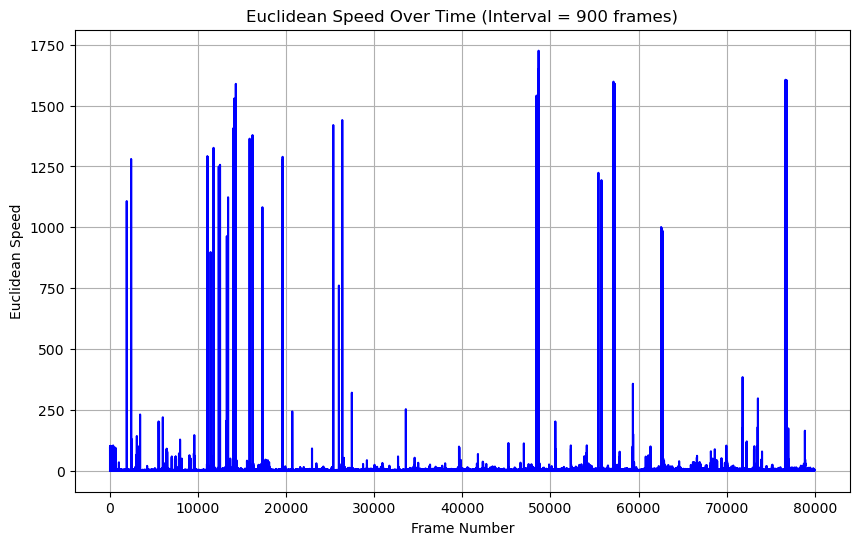

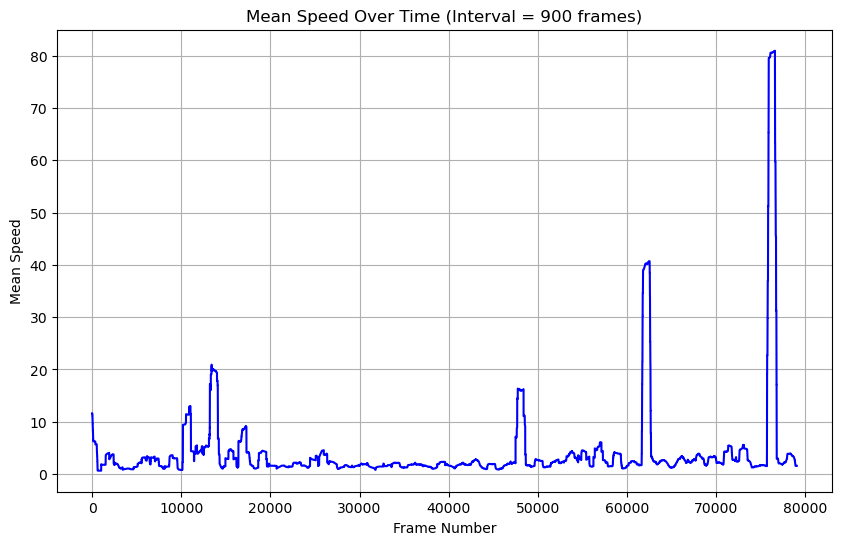

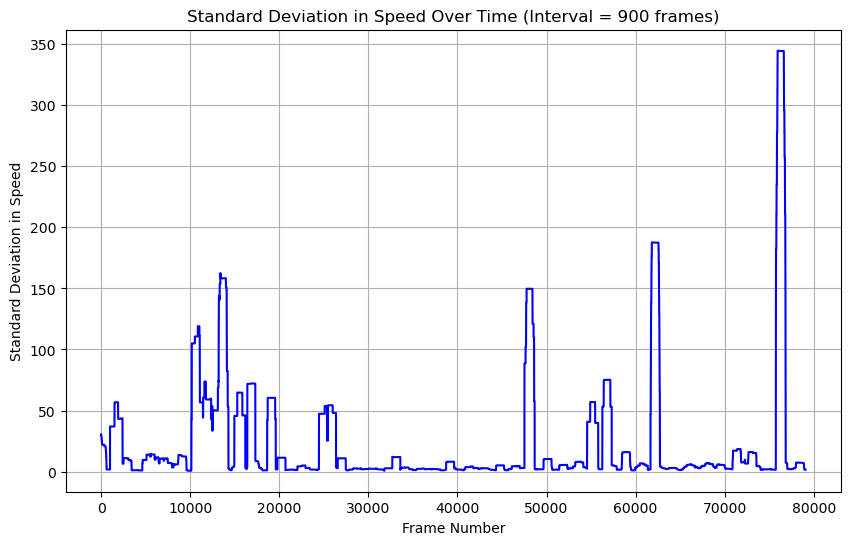

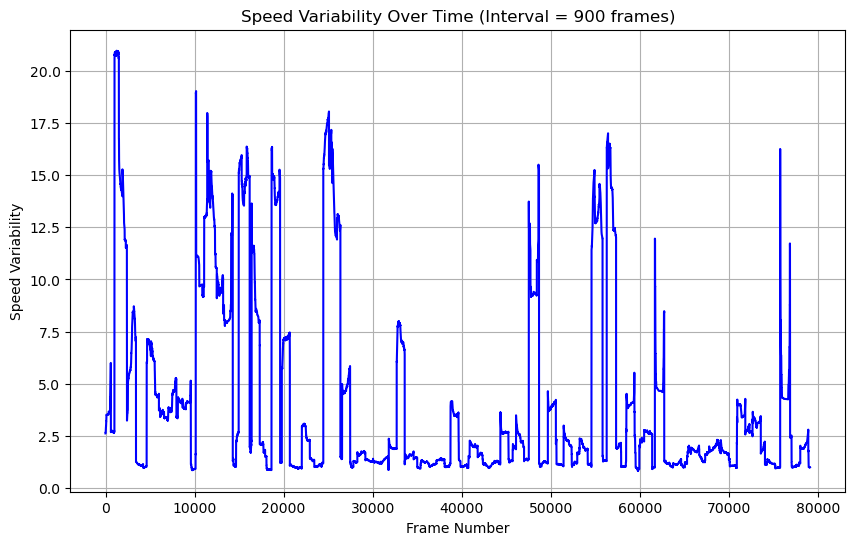

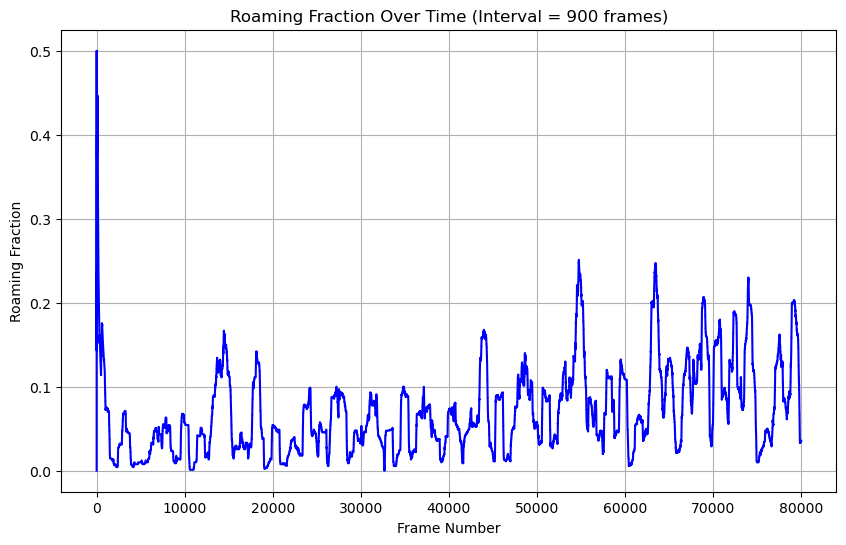

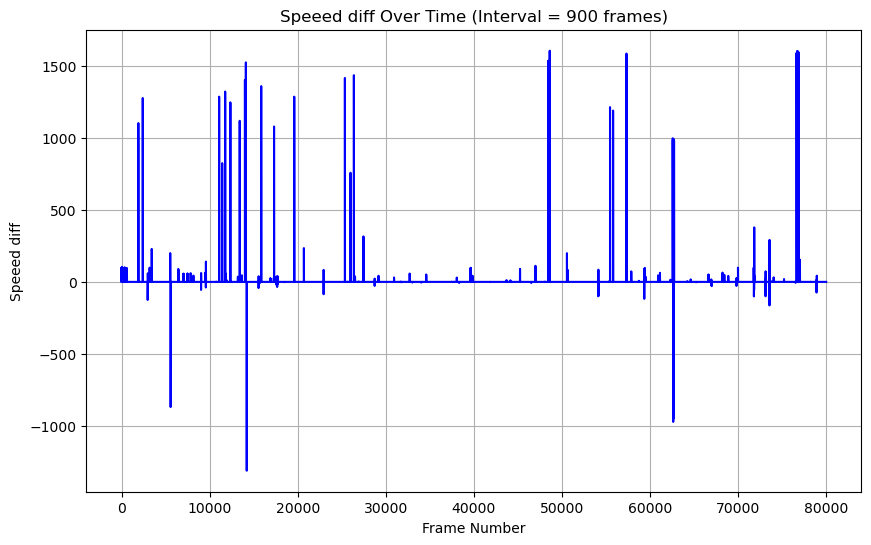

In [18]:
data = data_preprocess('Optogenetics-20241202T112946Z-001/Optogenetics/ATR+/speeds_and_coordinates_02piworm13_2_updated.csv')
data.head()

plot_data_over_interval(data.index, data['euclidean_speed'], x_label = "Frame Number", y_label="Euclidean Speed", interval=INTERVAL)
#plot_data_over_interval(data_updated.index, data_updated['Light_Pulse'], x_label = "Frame Number", y_label="Light Pulse", interval=INTERVAL)
plot_data_over_interval(data.index, data['mean_speed'], x_label = "Frame Number", y_label="Mean Speed", interval=INTERVAL)
plot_data_over_interval(data.index, data['std_speed'], x_label = "Frame Number", y_label="Standard Deviation in Speed", interval=INTERVAL)
plot_data_over_interval(data.index, data['speed_variability'], x_label = "Frame Number", y_label="Speed Variability", interval=INTERVAL)
plot_data_over_interval(data.index, data['roaming_frac'], x_label = "Frame Number", y_label="Roaming Fraction", interval=INTERVAL)
plot_data_over_interval(data.index, data['speed_diff'], x_label = "Frame Number", y_label="Speeed diff", interval=INTERVAL)



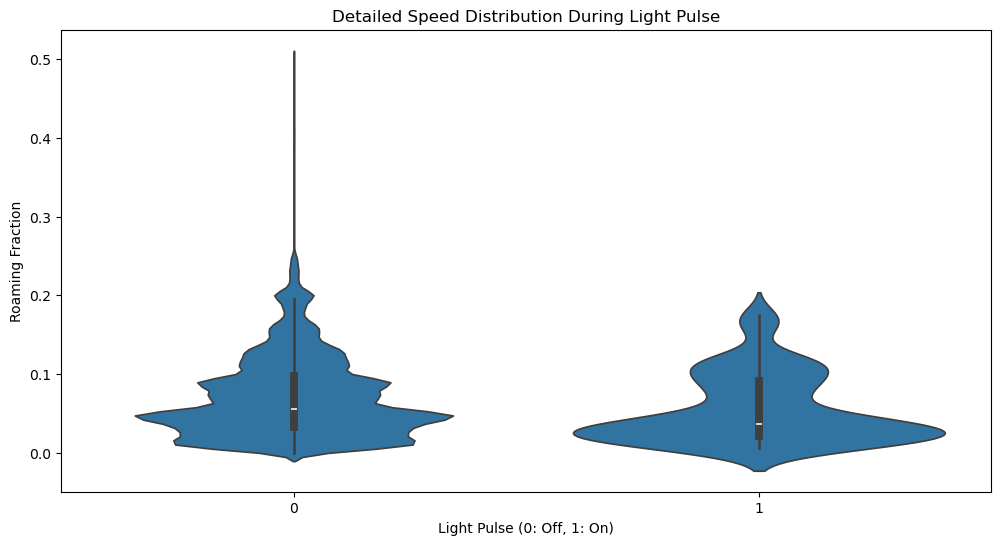

In [19]:
import seaborn as sns

def plotViolinBoxPLot(data):
    plt.figure(figsize=(12, 6))
    sns.violinplot(x='Light_Pulse', y='roaming_frac', data=data)
    plt.title('Detailed Speed Distribution During Light Pulse')
    plt.xlabel('Light Pulse (0: Off, 1: On)')
    plt.ylabel('Roaming Fraction')
    plt.show()
    
'''
plt.figure(figsize=(12, 6))
sns.violinplot(x='Light_Pulse', y='roaming_frac', data=data)
plt.title('Detailed Speed Distribution During Light Pulse')
plt.xlabel('Light Pulse (0: Off, 1: On)')
plt.ylabel('Roaming Fraction')
plt.show()'''

plotViolinBoxPLot(data)

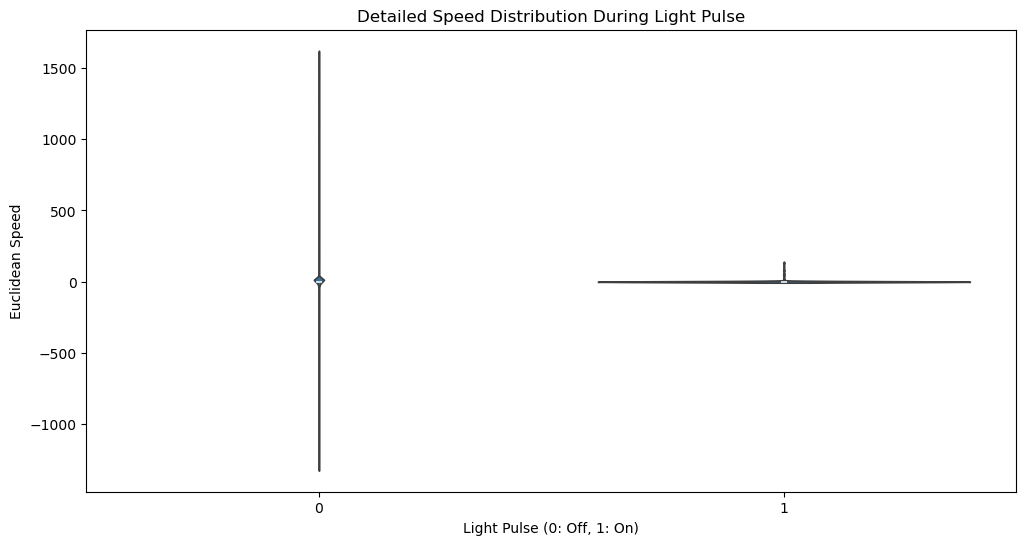

In [20]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(x='Light_Pulse', y='speed_diff', data=data)
plt.title('Detailed Speed Distribution During Light Pulse')
plt.xlabel('Light Pulse (0: Off, 1: On)')
plt.ylabel('Euclidean Speed')
plt.show()

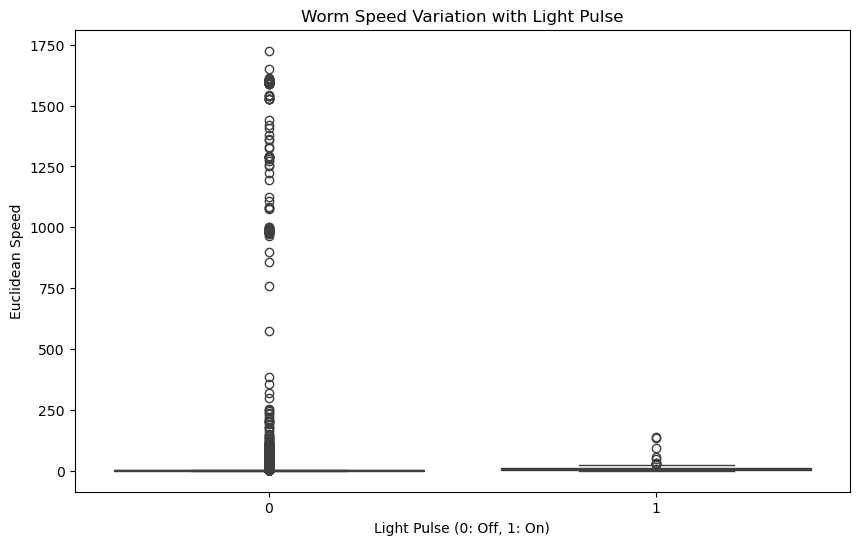

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Light_Pulse', y='euclidean_speed', data=data)
plt.title('Worm Speed Variation with Light Pulse')
plt.xlabel('Light Pulse (0: Off, 1: On)')
plt.ylabel('Euclidean Speed')
plt.show()

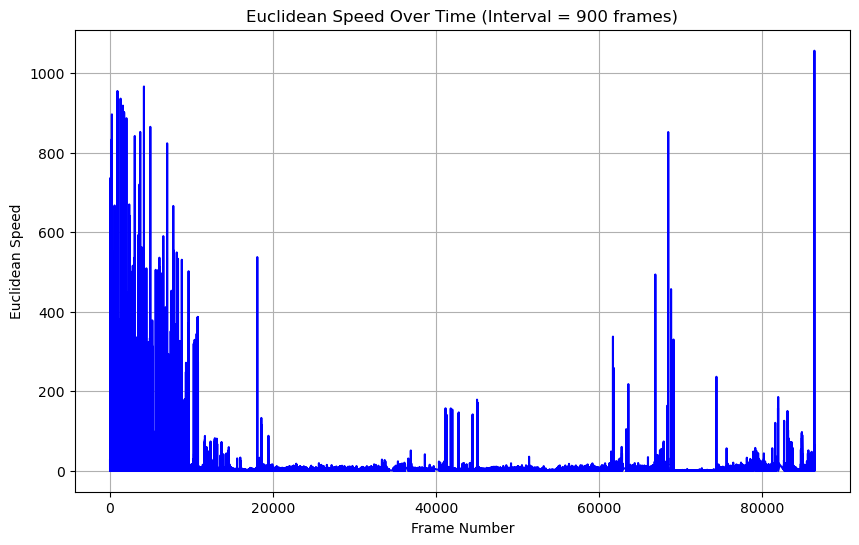

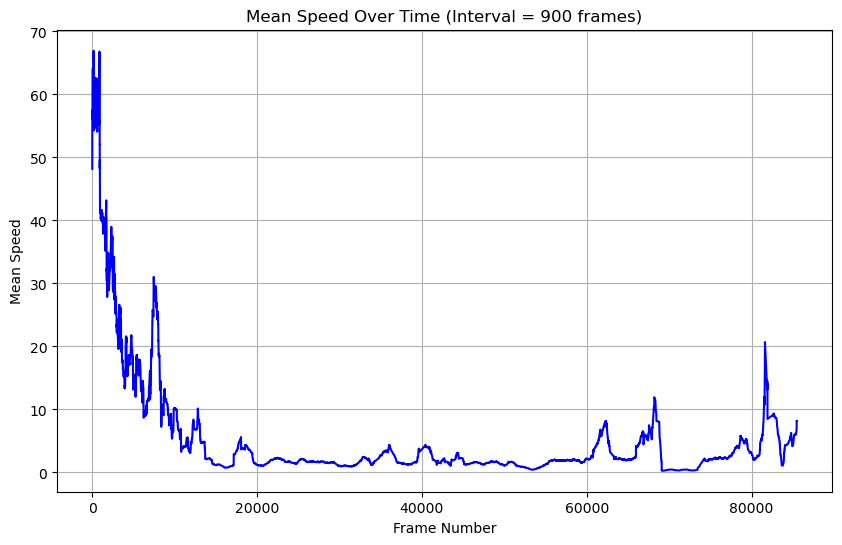

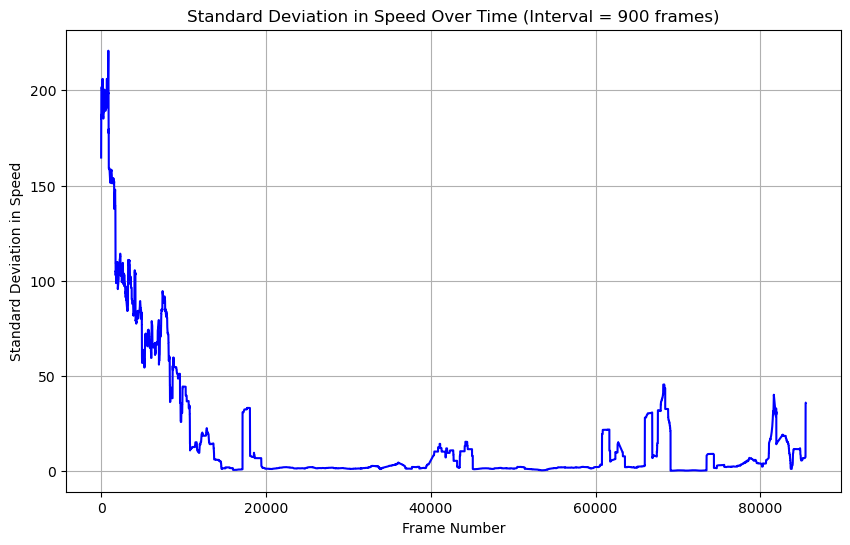

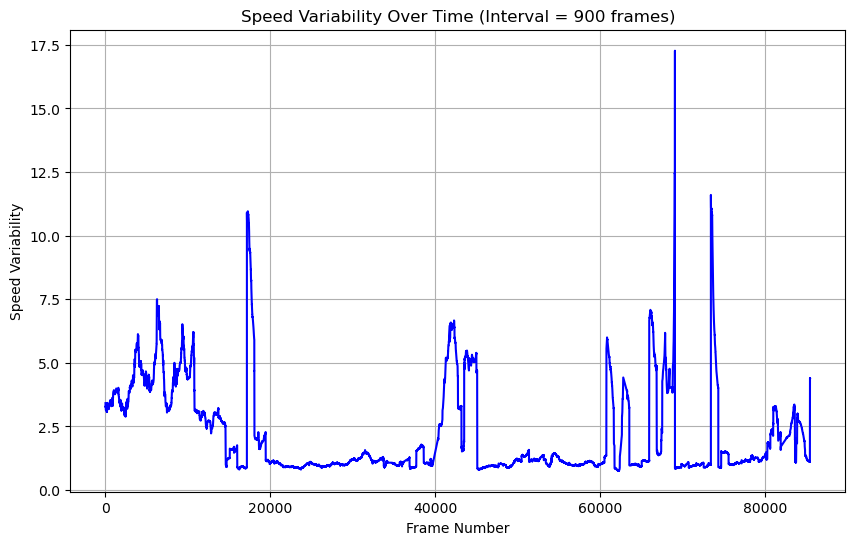

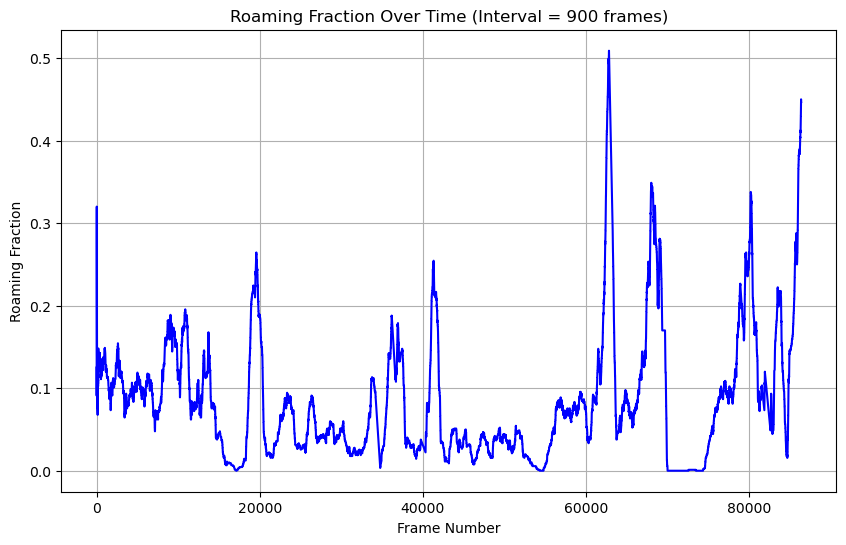

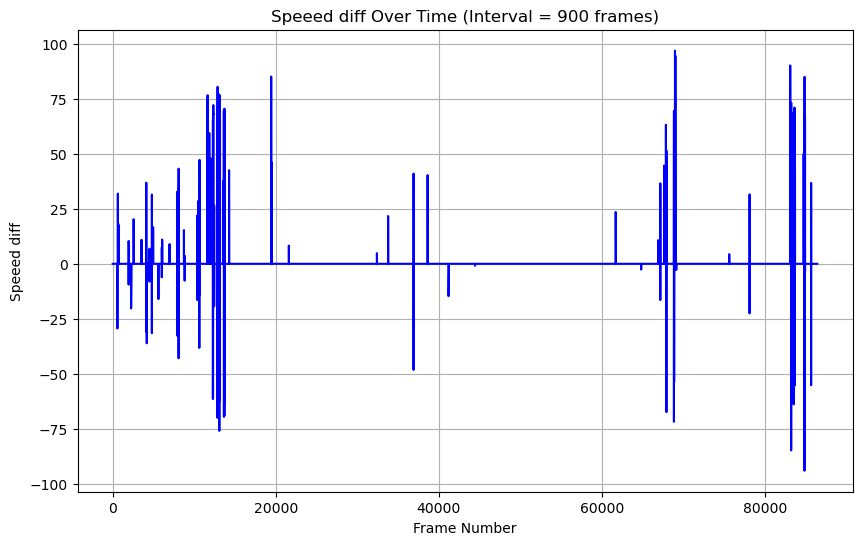

In [22]:
plot_data_over_interval(data_updated.index, data_updated['euclidean_speed'], x_label = "Frame Number", y_label="Euclidean Speed", interval=INTERVAL)
#plot_data_over_interval(data_updated.index, data_updated['Light_Pulse'], x_label = "Frame Number", y_label="Light Pulse", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['mean_speed'], x_label = "Frame Number", y_label="Mean Speed", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['std_speed'], x_label = "Frame Number", y_label="Standard Deviation in Speed", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['speed_variability'], x_label = "Frame Number", y_label="Speed Variability", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['roaming_frac'], x_label = "Frame Number", y_label="Roaming Fraction", interval=INTERVAL)
plot_data_over_interval(data_updated.index, data_updated['speed_diff'], x_label = "Frame Number", y_label="Speeed diff", interval=INTERVAL)

In [23]:
# CLustering
# 1) Drop irrelevant columns
# 2) Standardize/normalize the data


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

columns_to_standardize = ['X', 'Y', 'euclidean_speed', 'roaming_frac', 'std_speed', 'mean_speed', 'speed_variability', 'speed_diff', 'Angular Change', 'Total Distance', 'Instantaneous Distance']
data[columns_to_standardize] = (data[columns_to_standardize] - data[columns_to_standardize].mean()) / data[columns_to_standardize].std()
features_cluster = ['X', 'Y', 'euclidean_speed', 'roaming_frac', 'Angular Change']
cluster_data = data[features_cluster]
cluster_data = cluster_data.fillna(0)



features = ['X', 'Y', 'euclidean_speed', 'roaming_frac', 'std_speed', 'mean_speed', 'speed_variability', 'speed_diff', 'Angular Change', 'Total Distance', 'Instantaneous Distance',
            'time_seconds', 'RoamingIndic', 'Angular Change']
new_data = data[features]
new_data = data.fillna(0)

print(new_data.iloc[:, 0:13])
print(type(new_data))  # Should be numpy.ndarray or pandas.DataFrame
print(new_data.shape)  # Should be (n_samples, n_features)
print(new_data.dtypes)


covMatrix = np.cov(new_data, rowvar=False)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(covMatrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]
print ("values")
print (eigenvalues)
print ("vectors")
print (eigenvectors)
print(eigenvectors.shape)

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
print(explained_variance_ratio)

k = 6  # Change this based on your needs
top_eigenvectors = eigenvectors[:, :k]


# Transform the data to the new PCA space
pca_transformed_data = np.dot(new_data, top_eigenvectors)



kmeans = KMeans(n_clusters=3)  # Experiment with cluster numbers
kmeans.fit(pca_transformed_data)
labels = kmeans.labels_
print(labels)
#new_data['Behavior_Cluster'] = kmeans.fit_predict(X_scaled)

#cluster_summary = new_data.groupby('Behavior_Cluster')[features].mean()
#print(cluster_summary)



       Frame     Speed         X         Y  Changed Pixels  Light_Pulse  \
0          1  0.180192 -0.104838 -0.085587               2            0   
1          2  0.671926 -0.105116 -0.085024               8            0   
2          3  0.133671  0.300947 -0.272677               3            0   
3          4  0.142243  0.301599 -0.272779              22            0   
4          5  3.081254  0.300985 -0.273017              41            0   
...      ...       ...       ...       ...             ...          ...   
79977  10795  0.554954 -0.591380  0.888212              10            0   
79978  10796  0.814406 -0.588928  0.887346              12            0   
79979  10797  0.509209 -0.585987  0.885486               7            0   
79980  10798  1.257194 -0.584025  0.884414              19            0   
79981  10799  0.376977 -0.580293  0.881083              37            0   

       continuous_frames  Instantaneous Distance  Total Distance     Angle  \
0                    

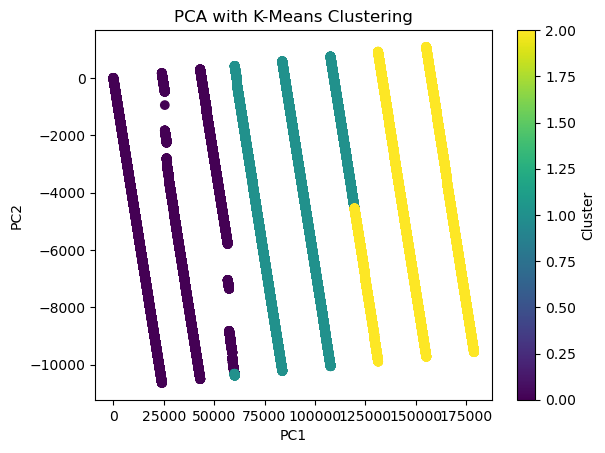

In [24]:
import matplotlib.pyplot as plt

# Plot the data points in the PCA-transformed space
plt.scatter(pca_transformed_data[:, 0], pca_transformed_data[:, 1], c=labels, cmap='viridis')

# Add labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA with K-Means Clustering')
plt.colorbar(label='Cluster')
plt.show()




[1 4 4 ... 0 0 0]


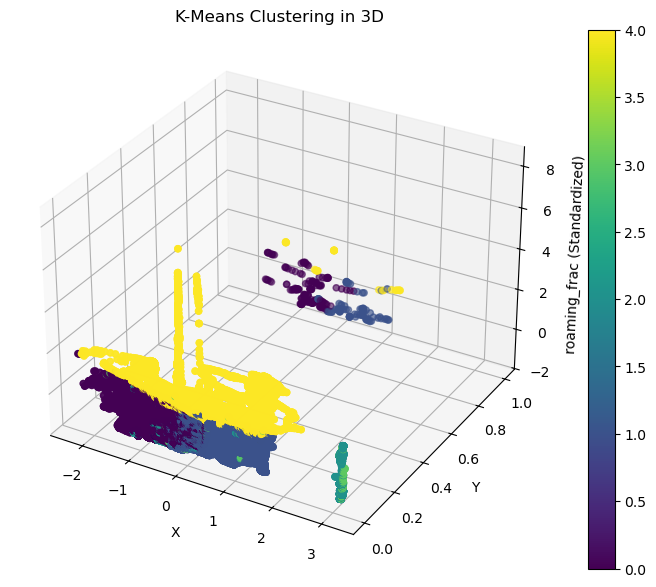

Cluster Centers (in standardized space):
[[-7.09619272e-01  4.00077708e-01  4.23637924e-03 -4.10730191e-02
  -3.01567357e-01]
 [ 5.37208212e-01 -1.57641305e-01  3.76609703e-03 -4.19730526e-02
  -4.30159223e-01]
 [ 1.99370506e+00 -3.62777935e+00 -1.43114687e-17 -6.70898241e-02
  -4.58174216e-01]
 [ 1.51460334e+00 -1.73466750e+00 -1.30104261e-18  2.44361993e+01
  -1.81856341e-01]
 [ 4.17310035e-01  1.37400191e-01  2.37049432e-03 -1.91216472e-02
   1.63889491e+00]]
Silhouette Score: 0.2992268764514871


In [25]:
features_cluster = ['X', 'Y', 'Light_Pulse', 'euclidean_speed', 'roaming_frac']
cluster_data = data[features_cluster]
cluster_data = cluster_data.fillna(0)

kmeans = KMeans(n_clusters=5) 
kmeans.fit(cluster_data)
labels = kmeans.labels_
#data['Cluster'] = labels

print(labels)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = cluster_data.values[:, 0]  # X
y = cluster_data.values[:, 2]  # Light Pulse
z = cluster_data.values[:, 4]  # Roaming Fraction

# Scatter plot with color based on cluster labels
ax.scatter(x, y, z, c=labels, cmap='viridis', marker='o')

# Add labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('roaming_frac (Standardized)')
ax.set_title('K-Means Clustering in 3D')

# Show colorbar to show which color corresponds to which cluster
plt.colorbar(ax.scatter(x, y, z, c=labels, cmap='viridis', marker='o'))

plt.show()

'''
plt.scatter(cluster_data.values[:, 2], cluster_data.values[:, 3], c=labels, cmap='viridis')
plt.xlabel('Speed (Standardized)')
plt.ylabel('Instantaneous Distance (Standardized)')
plt.title('K-Means Clustering on Standardized Data')
plt.colorbar(label='Cluster')
plt.show()
'''
# check the cluster centers
print("Cluster Centers (in standardized space):")
print(kmeans.cluster_centers_)

# evaluate the clustering with silhouette score
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(cluster_data, labels)
print(f'Silhouette Score: {silhouette_avg}')

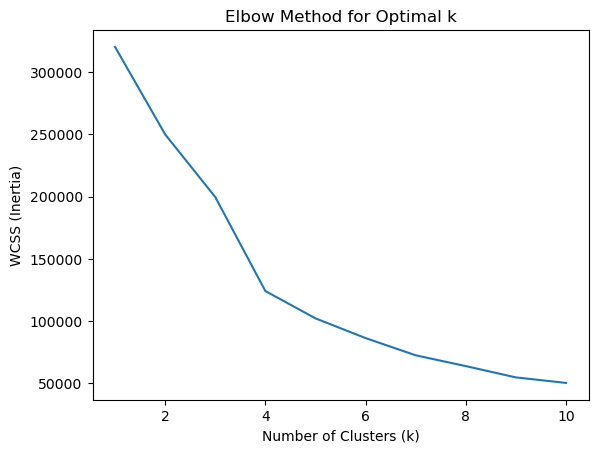

In [26]:
k_range = range(1, 11)

wcss = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_data)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.plot(k_range, wcss)
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.show()

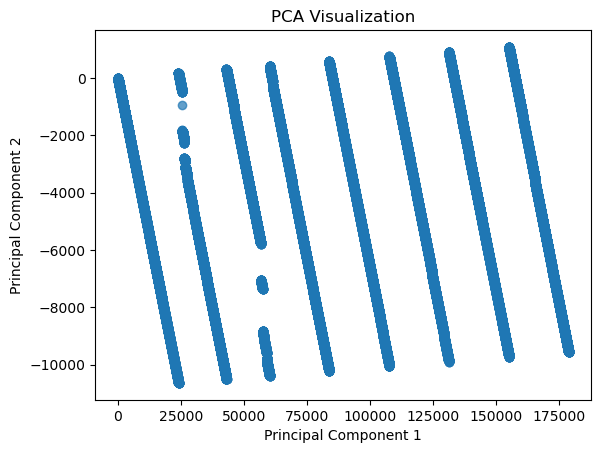

In [27]:

import matplotlib.pyplot as plt

# For 2D PCA
plt.scatter(pca_transformed_data[:, 0], pca_transformed_data[:, 1], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()


C:\Users\srush\AppData\Local\Temp\ipykernel_22024\2948715835.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


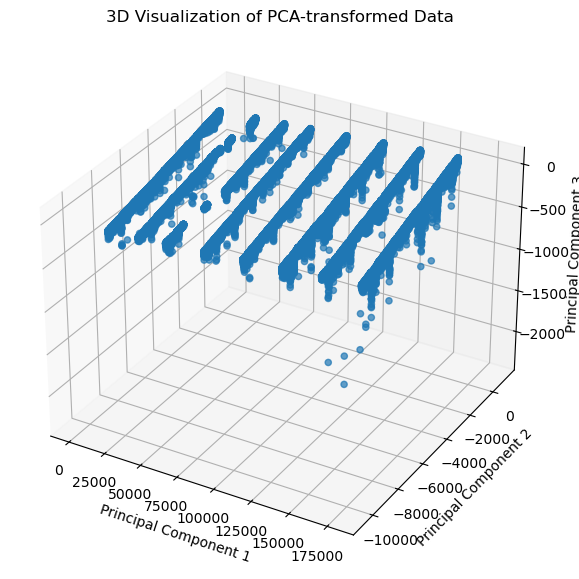

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with the first three principal components
ax.scatter(
    pca_transformed_data[:, 0],  # First principal component
    pca_transformed_data[:, 1],  # Second principal component
    pca_transformed_data[:, 2],  # Third principal componen
    cmap='viridis',             
    alpha=0.7  
)

# Label axes
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Set a title
ax.set_title('3D Visualization of PCA-transformed Data')

plt.show()


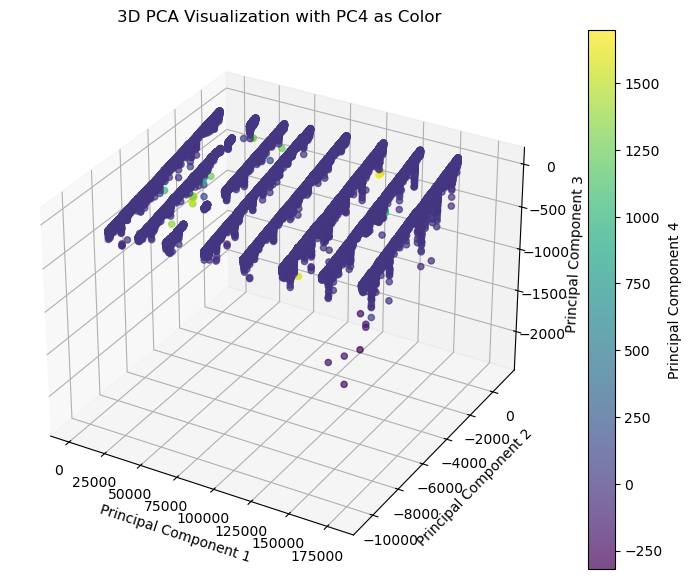

In [29]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Assuming the fourth principal component is represented as the color
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_transformed_data[:, 0],  # PC1
    pca_transformed_data[:, 1],  # PC2
    pca_transformed_data[:, 2],  # PC3
    c=pca_transformed_data[:, 3],  # PC4 represented as color
    cmap='viridis',  # Color map for the fourth dimension
    alpha=0.7
)

# Add color bar to indicate the values of the fourth dimension
colorbar = plt.colorbar(scatter)
colorbar.set_label('Principal Component 4')

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Visualization with PC4 as Color')
plt.show()
